<a href="https://colab.research.google.com/github/Tanvi-codez/Computer-vision/blob/main/fashioMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importing required libararies
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2



In [ ]:
#Downloading training and test data from open datasets.
training_data = datasets.FashionMNIST(
    root = "data", #tells pytorch where to save the dataset
    train = True, #helps differentiate training data and testing data
    download = True, #checks the specified folder for the data and downloads it if found empty
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale = True)]) #converts the images into data readable by the computer and assigns number in range 0 to 1 to all boxes.
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False, #do not want to train the computer on test data
    download = True,
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale = True)])
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 10.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 170kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.9MB/s]


In [ ]:
batch_size = 50 #can be changed to optimise

#Create data loaders.
train_dataloader = DataLoader(training_data, batch_size = batch_size)
test_dataloader = DataLoader(test_data, batch_size = batch_size)

for X,y in test_dataloader:
  print(f"Shape of X [N,C,H,W]: {X.shape}") #gives batch size , colour , height, width of the data
  print(f"Shape of y: {y.shape} {y.dtype}") #gives shape and datatype of the output type
  break

Shape of X [N,C,H,W]: torch.Size([50, 1, 28, 28])
Shape of y: torch.Size([50]) torch.int64


In [ ]:
#Creating the model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

#Define model
class NeuralNetwork(nn.Module): #automatically gives our class all the properties of the nn.module
  def __init__(self):
    super().__init__() #required to inherit nn.module
    self.flatten= nn.Flatten() #converts the 28x28 pixels data into a single 784 pieces of data
    self.linear_relu_stack = nn.Sequential( #gives sequence in which teh data should be processed
        nn.Linear(28*28, 512), #defines the first inner layer
        nn.ReLU(),
                                        #helps give shapes to the linear stacks by making negative values 0
        nn.Linear(512,512), #defines the second inner layer
        nn.ReLU(),

        nn.Linear(512,10) #as fashionMNIST has 10 types of clothing items, we end at 10 options
    )

  def forward(self,x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x) #pushes data through the nn.sequential sequence

    return logits #returns 10 random numbers giving confidence level of the AI for each item

model = NeuralNetwork().to(device)
print(model)

Using cuda device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
#Optimizing the Model Parameters
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
loss_fn = nn.CrossEntropyLoss() #Calculates the loss function
optimiser = torch.optim.SGD(model.parameters(), lr=1e-3) #helps train the neuralnetwork and optimise weights and biases, learning rate can be changed to optimise


In [ ]:
#training func

def train(dataloader, model, loss_fn, optimiser):
  size = len(dataloader.dataset)
  model.train()
  for batch, (X,y) in enumerate(dataloader): #batch counts number of stacks processed
    X,y = X.to(device) , y.to(device) #takes dataloader from computer RAM and sends to GPU where the model is

    #Compute prediction error
    pred = model(X)
    loss = loss_fn(pred,y)

    #BackPropagation
    loss.backward() #sends the loss backwards
    optimiser.step() #calculates gradient and determines optimisation

    optimiser.zero_grad() #sets gradient to 0

    if batch%100 == 0:
      loss,current = loss.item() , (batch+1)*len(X)
      print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")






In [ ]:
#testing funcn

def test(dataloader, model, loss_fn):
  size= len(dataloader.dataset)
  num_batches = len(dataloader)
  model.eval()
  test_loss, correct = 0, 0
  with torch.no_grad(): #sets the AI in testing mode that is no more calculating gradients
    for X,y in dataloader:
      X,y = X.to(device) , y.to(device)
      pred = model(X)
      test_loss += loss_fn(pred, y).item() #.item() converts the tensors we moving in back to readable data
      correct+= (pred.argmax(1) == y).type(torch.float).sum().item() #determines number of correct answers
  test_loss /= num_batches
  correct /= size

  print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss: >8f}\n")
  return test_loss, correct

In [ ]:
epochs = 20

# Re-initialize the scheduler to match the desired number of training epochs
# 'steps_per_epoch' and 'optimiser' are assumed to be globally defined from previous cells.
import torch.optim.lr_scheduler as lr_scheduler
steps_per_epoch = len(train_dataloader)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser,
    mode='max',      # because we're tracking accuracy
    factor=0.5,      # multiply lr by 0.5
    patience=3,       # wait 3 epochs
    threshold = 0
)


for t in range(epochs):
    print(f"Epoch {t+1}/{epochs}")


    train(train_dataloader, model, loss_fn, optimiser)

    test_loss, test_acc = test(
        test_dataloader,
        model,
        loss_fn
    )

    scheduler.step(test_acc)

    print(
        f"Accuracy: {test_acc:.4f}, "
        f"LR: {optimiser.param_groups[0]['lr']}"
    )

Epoch 1/20
loss: 0.195143 [   50/60000]
loss: 0.214872 [ 5050/60000]
loss: 0.109290 [10050/60000]
loss: 0.082275 [15050/60000]
loss: 0.112265 [20050/60000]
loss: 0.147310 [25050/60000]
loss: 0.077470 [30050/60000]
loss: 0.123171 [35050/60000]
loss: 0.387997 [40050/60000]
loss: 0.236657 [45050/60000]
loss: 0.318393 [50050/60000]
loss: 0.274469 [55050/60000]
Test Error: 
 Accuracy: 89.4%, Avg loss: 0.312214

Accuracy: 0.8939, LR: 0.001
Epoch 2/20
loss: 0.156053 [   50/60000]
loss: 0.215072 [ 5050/60000]
loss: 0.116013 [10050/60000]
loss: 0.092806 [15050/60000]
loss: 0.108489 [20050/60000]
loss: 0.150662 [25050/60000]
loss: 0.074579 [30050/60000]
loss: 0.120420 [35050/60000]
loss: 0.379475 [40050/60000]
loss: 0.231910 [45050/60000]
loss: 0.309087 [50050/60000]
loss: 0.270365 [55050/60000]
Test Error: 
 Accuracy: 89.4%, Avg loss: 0.312182

Accuracy: 0.8943, LR: 0.001
Epoch 3/20
loss: 0.154088 [   50/60000]
loss: 0.214211 [ 5050/60000]
loss: 0.115816 [10050/60000]
loss: 0.097176 [15050/6000

KeyboardInterrupt: 

In [ ]:
#saving the model

torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


In [ ]:
#loading the model

model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

In [ ]:
#using model for predictions

import os
import pandas as pd
from PIL import Image
import torch
from torchvision.transforms import v2




In [ ]:
model.eval()

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True)
])

image_folder = "images"

results = []

with torch.no_grad():
  for i in range(100):
    filename = f"{i:03d}.png"
    filepath = os.path.join(image_folder, filename)

    if os.path.exists(filepath):
      raw_img = Image.open(filepath)

      img_tensor = transform(raw_img).unsqueeze(0).to(device)

      logits = model(img_tensor)
      predicted_class = logits.argmax(1).item()

      results.append([i, predicted_class])
      print(f"Read {filename} --> Guessed: {predicted_class}")
    else:
      print(f"Warning: Could not find {filename}")

df = pd.DataFrame(results, columns = ["image_id" , "label"])
df.to_csv("2025MT11356_NN.csv", index = False)

print("\nFinished")



NameError: name 'os' is not defined

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



In [ ]:
y_true = [] #real answers
y_pred = [] #Ai's prediction

model.eval()

with torch.no_grad():
    for X, y in test_dataloader:

        X = X.to(device)
        y = y.to(device)

        outputs = model(X)

        predictions = outputs.argmax(dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

     T-shirt       0.85      0.84      0.85      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.79      0.85      0.82      1000
       Dress       0.87      0.91      0.89      1000
        Coat       0.83      0.81      0.82      1000
      Sandal       0.97      0.96      0.96      1000
       Shirt       0.76      0.70      0.72      1000
     Sneaker       0.94      0.95      0.95      1000
         Bag       0.97      0.96      0.97      1000
  Ankle Boot       0.96      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



[[842   0  20  24   4   2  97   0  11   0]
 [  2 971   0  20   3   0   2   0   2   0]
 [ 13   0 852  16  71   0  47   0   1   0]
 [ 23   4  15 912  19   1  22   0   4   0]
 [  1   1  92  40 813   0  51   0   2   0]
 [  0   0   0   1   0 962   0  21   1  15]
 [105   1  99  30  59   0 696   0  10   0]
 [  0   0   0   0   0  18   0 955   0  27]
 [  4   0   5   8   6   3   6   5 963   0]
 [  1   0   0   0   0   9   0  32   0 958]]


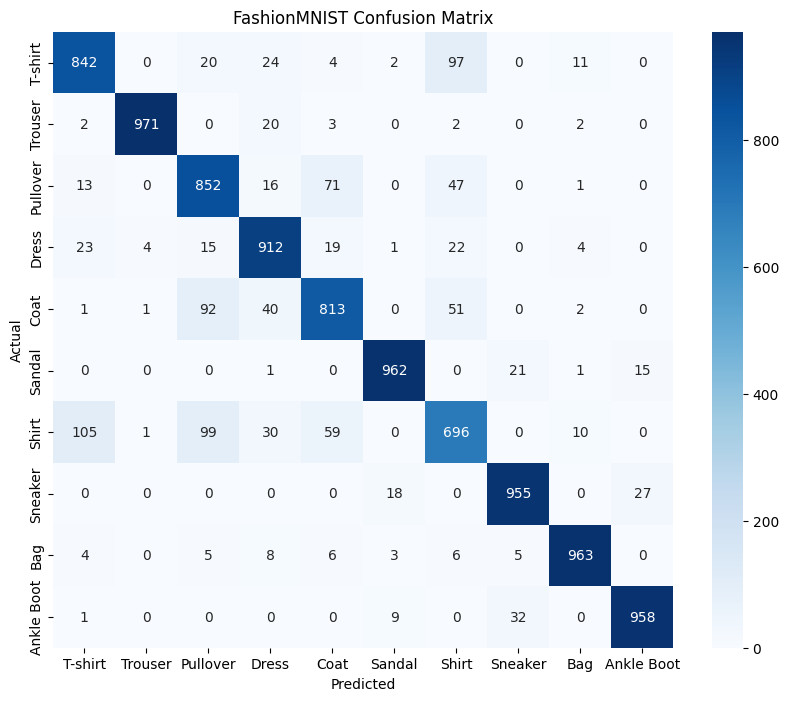

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("FashionMNIST Confusion Matrix")

plt.show()

CODE FOR CNN

In [ ]:
#code for CNN

In [ ]:
#importing required libararies
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2



In [ ]:
#Downloading training and test data from open datasets.
training_data = datasets.FashionMNIST(
    root = "data", #tells pytorch where to save the dataset
    train = True, #helps differentiate training data and testing data
    download = True, #checks the specified folder for the data and downloads it if found empty
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale = True)]) #converts the images into data readable by the computer and assigns number in range 0 to 1 to all boxes.
)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False, #do not want to train the computer on test data
    download = True,
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale = True)])
)

In [ ]:
batch_size = 64 #can be changed to optimise

#Create data loaders.
train_dataloader = DataLoader(training_data, batch_size = batch_size)
test_dataloader = DataLoader(test_data, batch_size = batch_size)

for X,y in test_dataloader:
  print(f"Shape of X [N,C,H,W]: {X.shape}") #gives batch size , colour , height, width of the data
  print(f"Shape of y: {y.shape} {y.dtype}") #gives shape and datatype of the output type
  break

Shape of X [N,C,H,W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [ ]:
#Creating the model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

#Define model
class CNN(nn.Module): #automatically gives our class all the properties of the nn.module
  def __init__(self):
    super().__init__() #required to inherit nn.module
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels = 32, kernel_size = 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels = 64, kernel_size = 3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.flatten= nn.Flatten() #converts the 28x28 pixels data into a single 784 pieces of data
    self.linear_relu_stack = nn.Sequential( #gives sequence in which teh data should be processed
        nn.Linear(64*7*7, 512), #defines the first inner layer
        nn.ReLU(), #helps give shapes to the linear stacks by making negative values
        nn.Linear(512,10) #as fashionMNIST has 10 types of clothing items, we end at 10 options
    )

  def forward(self,x):
    x = self.conv_block_1(x)
    x = self.conv_block_2(x)
    x = self.flatten(x)
    logits = self.linear_relu_stack(x) #pushes data through the nn.sequential sequence

    return logits #returns 10 random numbers giving confidence level of the AI for each item

model2 = CNN().to(device)
print(model2)

Using cuda device
CNN(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [ ]:
#Optimizing the Model Parameters

loss_fn = nn.CrossEntropyLoss() #Calculates the loss function
optimiser = torch.optim.SGD(model2.parameters(), lr=1e-2) #helps train the neuralnetwork and optimise weights and biases, learning rate can be changed to optimis

In [ ]:
#training func

def train(dataloader, model, loss_fn, optimiser):
  size = len(dataloader.dataset)
  model2.train()
  for batch, (X,y) in enumerate(dataloader): #batch counts number of stacks processed
    X,y = X.to(device) , y.to(device) #takes dataloader from computer RAM and sends to GPU where the model is

    #Compute prediction error
    pred = model(X)
    loss = loss_fn(pred,y)

    #BackPropagation
    loss.backward() #sends the loss backwards
    optimiser.step() #calculates gradient and determines optimisation
    optimiser.zero_grad() #sets gradient to 0

    if batch%100 == 0:
      loss,current = loss.item() , (batch+1)*len(X)
      print(f"loss: {loss:>7f} [{current:>5d}/{size:>5d}]")






In [ ]:
def test(dataloader, model, loss_fn):
  size= len(dataloader.dataset)
  num_batches = len(dataloader)
  model2.eval()
  test_loss2, correct2 = 0, 0
  with torch.no_grad(): #sets the AI in testing mode that is no more calculating gradients
    for X,y in dataloader:
      X,y = X.to(device) , y.to(device)
      pred = model(X)
      test_loss2 += loss_fn(pred, y).item() #.item() converts the tensors we moving in back to readable data
      correct2+= (pred.argmax(1) == y).type(torch.float).sum().item() #determines number of correct answers
  test_loss2 /= num_batches
  correct2 /= size
  print(f"Test Error: \n Accuracy: {(100*correct2):>0.1f}%, Avg loss: {test_loss2: >8f}\n")
  return test_loss2, correct2

In [ ]:
epochs = 50

# Re-initialize the scheduler to match the desired number of training epochs
# 'steps_per_epoch' and 'optimiser' are assumed to be globally defined from previous cells.
import torch.optim.lr_scheduler as lr_scheduler
steps_per_epoch = len(train_dataloader)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser,
    mode='max',      # because we're tracking accuracy
    factor=0.5,      # multiply lr by 0.5
    patience=3,       # wait 3 epochs
    threshold = 0
)


for t in range(epochs):
    print(f"Epoch {t+1}/{epochs}")


    train(train_dataloader, model2, loss_fn, optimiser)

    test_loss2, correct2 = test(
        test_dataloader,
        model2,
        loss_fn
    )

    scheduler.step(correct2)

    print(
        f"Accuracy: {correct2:.4f}, "
        f"LR: {optimiser.param_groups[0]['lr']}"
    )

Epoch 1/50
loss: 0.092628 [   64/60000]
loss: 0.116101 [ 6464/60000]
loss: 0.077404 [12864/60000]
loss: 0.143770 [19264/60000]
loss: 0.216209 [25664/60000]
loss: 0.304710 [32064/60000]
loss: 0.219507 [38464/60000]
loss: 0.165731 [44864/60000]
loss: 0.183534 [51264/60000]
loss: 0.165321 [57664/60000]
Test Error: 
 Accuracy: 90.9%, Avg loss: 0.258982

Accuracy: 0.9094, LR: 0.01
Epoch 2/50
loss: 0.094827 [   64/60000]
loss: 0.112832 [ 6464/60000]
loss: 0.075490 [12864/60000]
loss: 0.141566 [19264/60000]
loss: 0.213984 [25664/60000]
loss: 0.302267 [32064/60000]
loss: 0.218911 [38464/60000]
loss: 0.164166 [44864/60000]
loss: 0.180076 [51264/60000]
loss: 0.163608 [57664/60000]
Test Error: 
 Accuracy: 91.0%, Avg loss: 0.258468

Accuracy: 0.9102, LR: 0.01
Epoch 3/50
loss: 0.092720 [   64/60000]
loss: 0.111552 [ 6464/60000]
loss: 0.074311 [12864/60000]
loss: 0.137825 [19264/60000]
loss: 0.207188 [25664/60000]
loss: 0.297456 [32064/60000]
loss: 0.214148 [38464/60000]
loss: 0.164891 [44864/60000]

KeyboardInterrupt: 

In [ ]:
#saving the model

torch.save(model2.state_dict(), "model2.pth")
print("Saved PyTorch Model State to model2.pth")

Saved PyTorch Model State to model.pth


In [ ]:
#loading the model

model2 = CNN().to(device)
model2.load_state_dict(torch.load("model2.pth", weights_only=True))

<All keys matched successfully>

In [ ]:
#using model for predictions

import os
import pandas as pd
from PIL import Image
import torch
from torchvision.transforms import v2




In [ ]:
model2.eval()

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale = True)
])

image_folder = "images"

results = []

with torch.no_grad():
  for i in range(100):
    filename = f"{i:03d}.png"
    filepath = os.path.join(image_folder, filename)

    if os.path.exists(filepath):
      raw_img = Image.open(filepath)

      img_tensor = transform(raw_img).unsqueeze(0).to(device)

      logits = model(img_tensor)
      predicted_class = logits.argmax(1).item()

      results.append([i, predicted_class])
      print(f"Read {filename} --> Guessed: {predicted_class}")
    else:
      print(f"Warning: Could not find {filename}")

df = pd.DataFrame(results, columns = ["image_id " , "label"])
df.to_csv("my_predictions2.csv", index = False)

print("\nFinished")




Finished


In [ ]:
y_true = [] #real answers
y_pred = [] #Ai's prediction

model2.eval()

with torch.no_grad():
    for X, y in test_dataloader:

        X = X.to(device)
        y = y.to(device)

        outputs = model2(X)

        predictions = outputs.argmax(dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

class_names = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

     T-shirt       0.86      0.86      0.86      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.88      0.86      0.87      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.87      0.86      0.87      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.76      0.78      0.77      1000
     Sneaker       0.95      0.98      0.96      1000
         Bag       0.99      0.98      0.98      1000
  Ankle Boot       0.98      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



[[863   1  14  12   4   1  99   0   6   0]
 [  2 982   2  10   3   0   0   0   1   0]
 [ 24   2 861   7  42   0  64   0   0   0]
 [ 15   8   9 923  20   0  22   0   3   0]
 [  2   0  46  31 862   0  59   0   0   0]
 [  0   0   0   1   0 980   0  14   0   5]
 [ 99   1  39  21  57   0 780   0   3   0]
 [  0   0   0   0   0   8   0 979   0  13]
 [  4   1   2   3   2   1   2   3 982   0]
 [  0   0   0   0   0   6   1  38   0 955]]


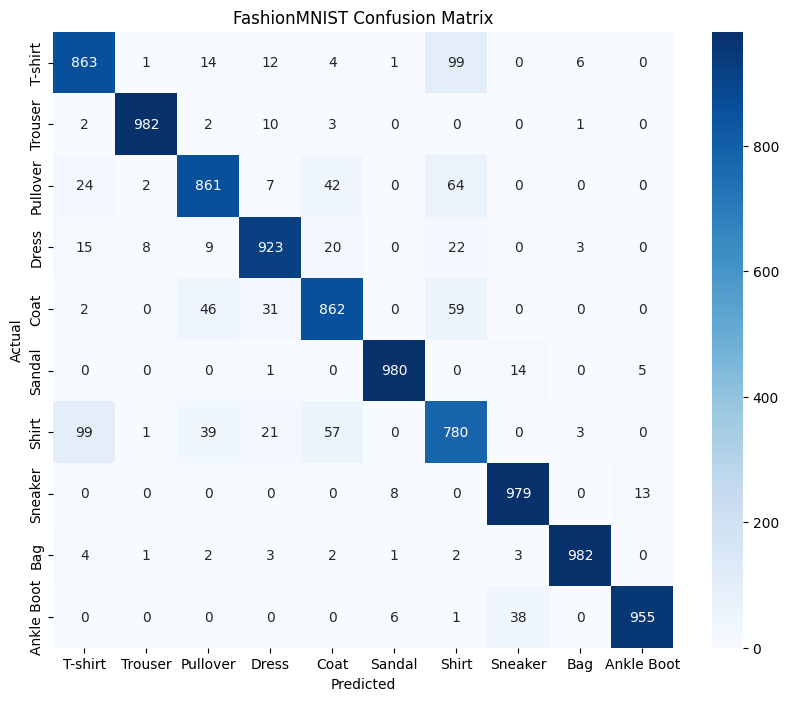

In [ ]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("FashionMNIST Confusion Matrix")

plt.show()